In [1]:
# !pip uninstall -y oceanttds

In [2]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path('.cache').resolve()))
os.environ.setdefault('MPLCONFIGDIR', str(Path('.cache/matplotlib').resolve()))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
# import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

import jax
import jax.numpy as jnp
import numpyro
import xarray_jax  # noqa: F401 - registers xarray objects as JAX pytrees
from numpyro import distributions as dist, sample
from numpyro.infer import MCMC, NUTS, Predictive
numpyro.set_host_device_count(4)
jax.local_device_count()


4

In [3]:
import cmocean.cm as cmo

In [4]:
ds_path = "/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_2010-2014.zarr"
ds = xr.open_mfdataset(ds_path)

In [5]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path)
ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -2500)

In [6]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_boundary_sample_for_ttd.zarr"
ds_b = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__":"boundary_truth"}).fillna(0.0)

ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_interior_sample_for_ttd.zarr"
ds_i = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__": "interior_truth"}).fillna(0.0)

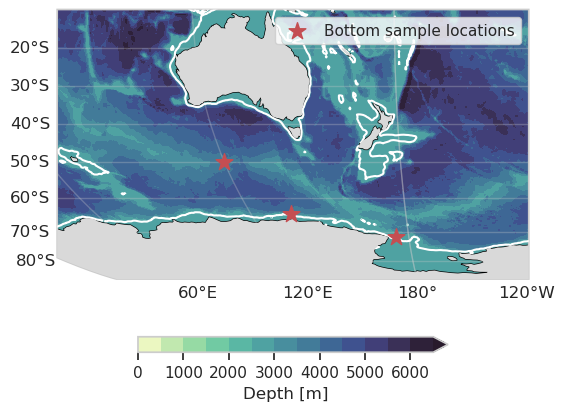

In [7]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-165)),
)

depth = ds.deptho.where(ds.deptho > 10).compute()
levels = np.arange(0, 7000, 500)

pc = ax.contourf(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = levels,extend = "max", 
                cmap = cmo.deep)
ax.contour(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = [1000.0], colors = "white", zorder = 8)

ax.scatter(ds_b.sel(source = "ross").lon, ds_b.sel(source = "ross").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_b.sel(source = "adelie").lon, ds_b.sel(source = "adelie").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_i.lon, ds_i.lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*", label = "Bottom sample locations")

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=8)
ax.coastlines()
# Australian Basin (approx): lon 80E–170E, lat 60S–10S
ax.set_extent([80, 220, -89, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(pc, ax = ax, orientation = "horizontal", shrink = 0.5, label = "Depth [m]")
legend = ax.legend(loc='upper right')

# Set the z-order of the legend (e.g., to a high value like 10)
legend.set_zorder(15) #
fig.savefig('plots/1.ttd_example_locations.png', dpi = 150, bbox_inches = "tight")

In [69]:
final_obs_year = 2090
ds_b["boundary"] = ds_b["boundary_truth"].fillna(0.0).copy()
ds_b = ds_b.sel(time = slice(None, final_obs_year))


ds_i["interior"] = ds_i["interior_truth"].fillna(0.0).copy()
ds_i = ds_i.sel(time = slice(1940, final_obs_year))

noise_floors = np.array([0.01, 0.01, 0.01])
ds_i = ds_i.assign(noise_floors=(("tracer",), noise_floors))
ds_i["sigma_obs"] = ds_i["noise_floors"].broadcast_like(ds_i["interior"])
# ds_i["sigma_obs"] = xr.where(
#     ds_i["interior"] * 0.01 > ds_i["noise_floors"],
#     ds_i["interior"] * 0.01,
#     ds_i["noise_floors"],
# )

truth = ds_i.copy()

In [70]:
expt_colors = {"forced":"r", "control":"k"}
variable_units = {"cfc11":r"pmol kg$^{-1}$", "cfc12":r"pmol kg$^{-1}$", "sf6":r"fmol kg$^{-1}$"}

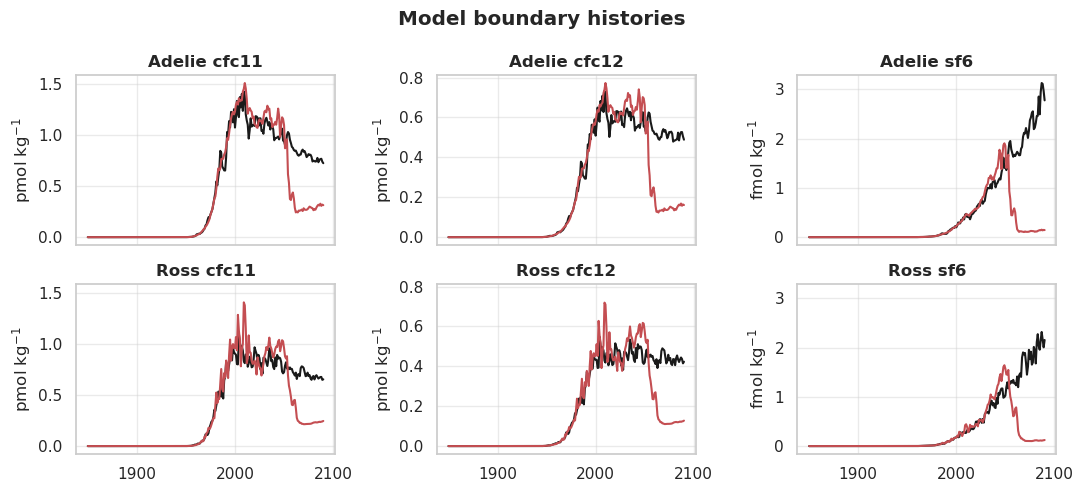

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharex=True, sharey='col')
for i, source in enumerate(ds_b.source.values):
    for j, tracer in enumerate(ds_b.tracer.values):
        for k, expt in enumerate(ds_b.expt.values):
            ax = axes[i, j]
            ax.plot(ds_b.time, ds_b.boundary.sel(source=source, 
                                                 tracer=tracer, 
                                                 expt = expt),
                                                 label = expt,
                                                 color=expt_colors[expt])
            ax.set_title(f'{source.capitalize()} {tracer}', fontweight='bold')
            ax.grid(alpha=0.4)
            ax.set_ylabel(variable_units[tracer])

fig.suptitle('Model boundary histories', fontweight='bold')
fig.tight_layout()

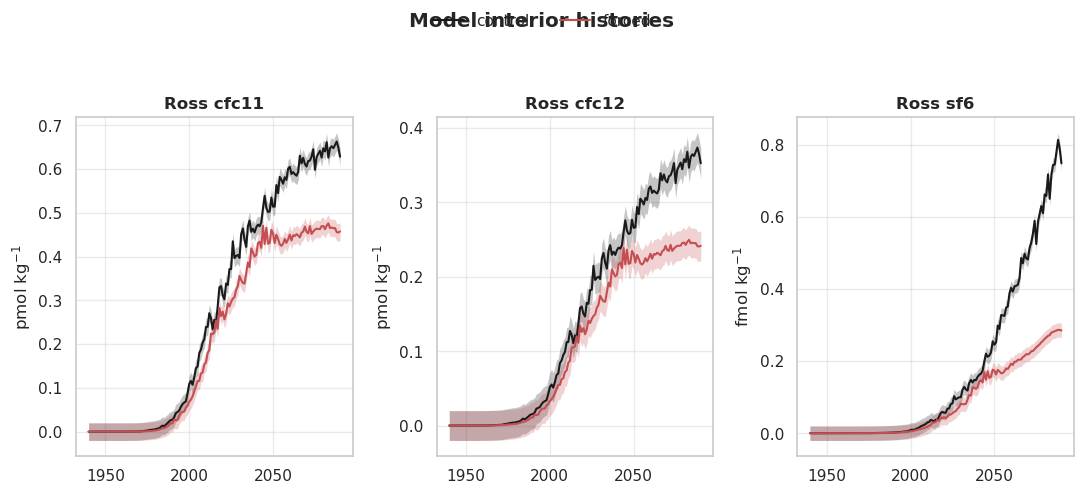

In [72]:
def plot_error_band(ax, time, history, error, label, color, legend=None, alpha=0.25):
    if legend is None:
        legend = {}

    ax.fill_between(time, history - 2 * error, history + 2 * error,
                    color=color, alpha=alpha, linewidth=0)
    line, = ax.plot(time, history, color=color)

    legend[label] = line
    return legend


fig, axes = plt.subplots(1, 3, figsize=(11, 5), sharex=True, sharey='col')
legend = {}

for ax, tracer in zip(axes, ds_i.tracer.values):
    for expt in ds_i.expt.values:
        history = ds_i.interior.sel(tracer=tracer, expt=expt)
        error = ds_i.sigma_obs.sel(tracer=tracer, expt=expt)
        legend = plot_error_band(ax, ds_i.time, history, error, expt,
                                 expt_colors[expt], legend)

    ax.set_title(f'{source.capitalize()} {tracer}', fontweight='bold')
    ax.set_ylabel(variable_units[tracer])
    ax.grid(alpha=0.4)

fig.legend(legend.values(), legend.keys(), loc="upper center",
           ncol=len(legend), frameon=False)
fig.suptitle('Model interior histories', fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])

In [73]:
from plot_ig_utils import *
from utils import *

bayes_integrator = TTDIntegrator(order=61)
def two_source_numpyro_model(ds_i, ds_b):
    n_source = ds_b.sizes['source']
    gamma = sample('gamma', dist.Uniform(1e-3, 5_000.0), sample_shape=(n_source,))
    delta_gamma_ratio = sample('delta_gamma_ratio', dist.Uniform(0.2, 2.2), sample_shape=(n_source,))
    mass_fraction = sample('mass_fraction', dist.Dirichlet(jnp.ones(n_source)))
    delta = gamma * delta_gamma_ratio

    gamma_da = xr.DataArray(gamma, dims='source', coords={'source': ds_b.source})
    delta_da = xr.DataArray(delta, dims='source', coords={'source': ds_b.source})
    mf_da = xr.DataArray(mass_fraction, dims='source', coords={'source': ds_b.source})
    mu = bayes_integrator.predict_sources(
        gamma=gamma_da, delta=delta_da, mass_fraction=mf_da,
        obs_times=ds_i['time'], boundary_time=ds_b['time'], boundary=ds_b['boundary'],
    )
    sample('obs', dist.Normal(loc=mu.data, scale=ds_i['sigma_obs'].data), obs=ds_i['interior'].data)

In [74]:
def add_timescale_vars(ds):
    ds["delta"] = ds["gamma"] * ds["delta_gamma_ratio"]
    ds["peclet"] = ds["delta_gamma_ratio"] ** 2 / 2.0
    ds["advective_timescale"] = ds["gamma"]
    ds["peclet_number"] = ds["peclet"]
    ds["diffusive_timescale"] = ds["gamma"] * ds["peclet"]
    return ds


def run_mcmc(ds_i, ds_b, expt=None):
    ds_i_e, ds_b_e = ds_i.sel(expt=expt), ds_b.sel(expt=expt)
    kernel = NUTS(two_source_numpyro_model, target_accept_prob=0.9)
    mcmc = MCMC(kernel, num_warmup=500, num_samples=2000, num_chains=4,
                chain_method="parallel", progress_bar=True)

    mcmc.run(jax.random.PRNGKey(2212), ds_i=ds_i_e, ds_b=ds_b_e,
             extra_fields=("diverging", "potential_energy"))

    posterior = flatten_numpyro_output(posterior=mcmc, source=ds_b_e.source)
    posterior = posterior.assign_coords(sample=np.arange(posterior.sizes["sample"]))
    posterior = add_timescale_vars(posterior)

    n_divergent = int(np.asarray(mcmc.get_extra_fields(group_by_chain=False)["diverging"]).sum())
    print("n_posterior =", posterior.sizes["sample"])
    print("n_divergent =", n_divergent)

    prior_draws = Predictive(two_source_numpyro_model, num_samples=posterior.sizes["sample"])(
        jax.random.PRNGKey(98712), ds_i=ds_i_e, ds_b=ds_b_e
    )

    prior = flatten_numpyro_output(group="prior", prior=prior_draws,
                                   sample_dims=["sample"], sample=posterior["sample"],
                                   source=ds_b_e.source)
    prior = add_timescale_vars(prior)

    return mcmc, prior, posterior

In [75]:
mcmc_control, prior_control, posterior_control = run_mcmc(ds_i.compute(), ds_b.compute(), expt = "control")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

n_posterior = 8000
n_divergent = 0


In [76]:
mcmc_forced, prior_forced, posterior_forced = run_mcmc(ds_i.compute(), ds_b.compute(), expt = "forced")

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

n_posterior = 8000
n_divergent = 13


In [101]:
def concat_by_expt(ds_control, ds_forced): 
    ds_out = xr.concat([ds_control, ds_forced], dim="expt")
    ds_out = ds_out.assign_coords(expt=["control", "forced"])
    return ds_out

def calculate_mixture_parameters(ds): #from the definitions of Gamma and Delta 
    f = ds["mass_fraction"]
    gamma = ds["gamma"]
    delta = ds["delta"]
    
    ds["gamma_mix"] = (f * gamma).sum("source")
    
    ds["delta_mix"] = np.sqrt(
        (f * delta**2).sum("source")
        + (f * (gamma - posterior["gamma_mix"])**2).sum("source"))
    return ds

In [102]:
posterior = concat_by_expt(posterior_control, posterior_forced)
prior = concat_by_expt(prior_control, prior_forced)

posterior = calculate_mixture_parameters(posterior)
prior = calculate_mixture_parameters(prior)

In [107]:
tracer_ds = xr.merge([ds_i.rename({"time":"interior_time"}), ds_b.rename({"time":"boundary_time"})], compat = "override")
bayes_ds = xr.concat([prior, posterior], dim="distribution")
bayes_ds = bayes_ds.assign_coords(distribution=["prior", "posterior"])

In [110]:
merged_ds = xr.merge([bayes_ds, tracer_ds], compat='override')
merged_ds.to_netcdf("/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bayesian_inverse_gaussian_results.nc")

control
forced


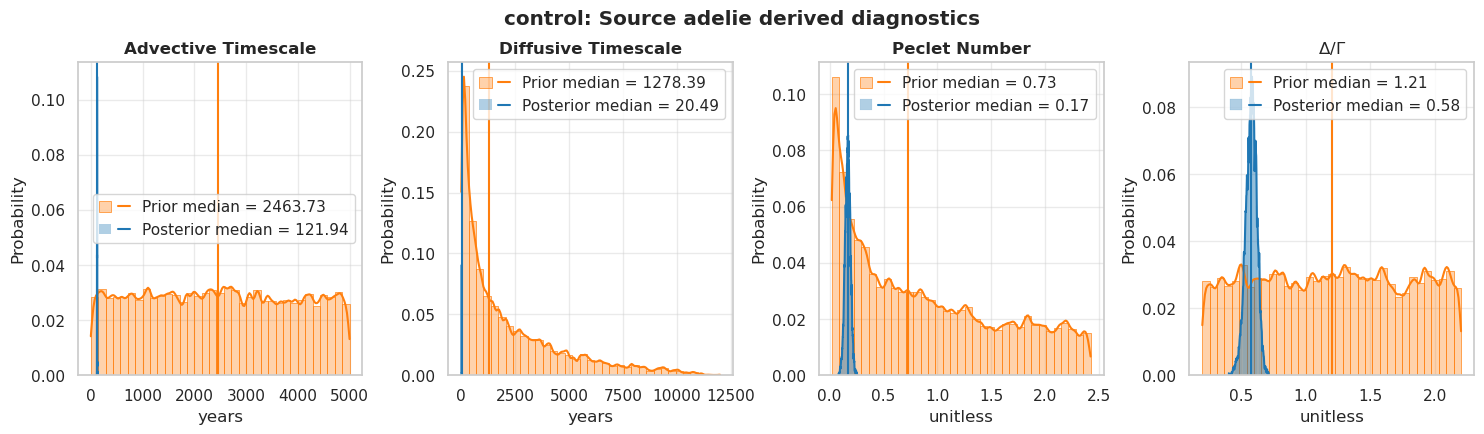

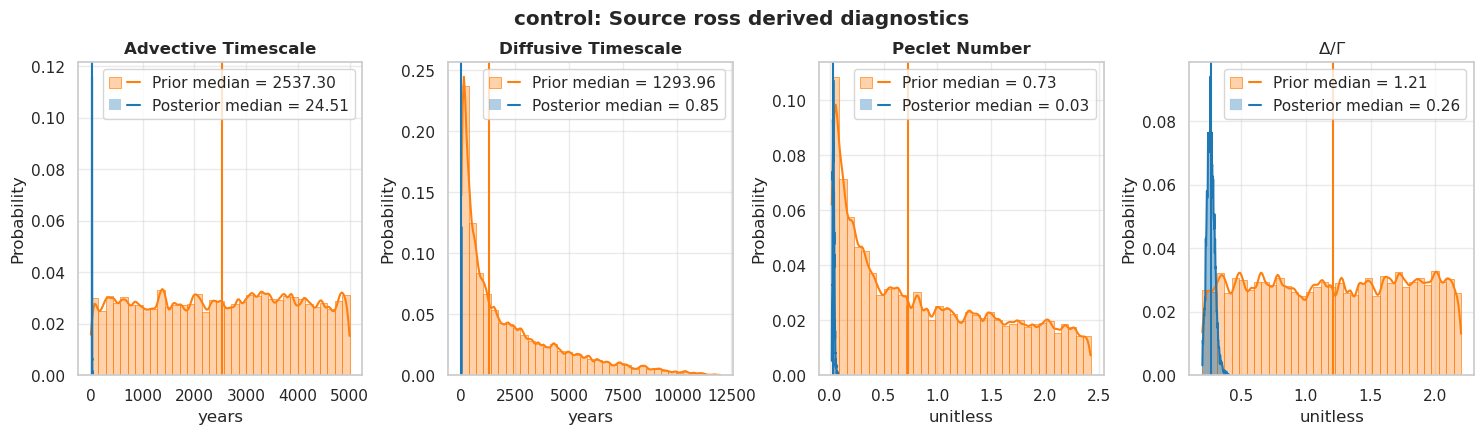

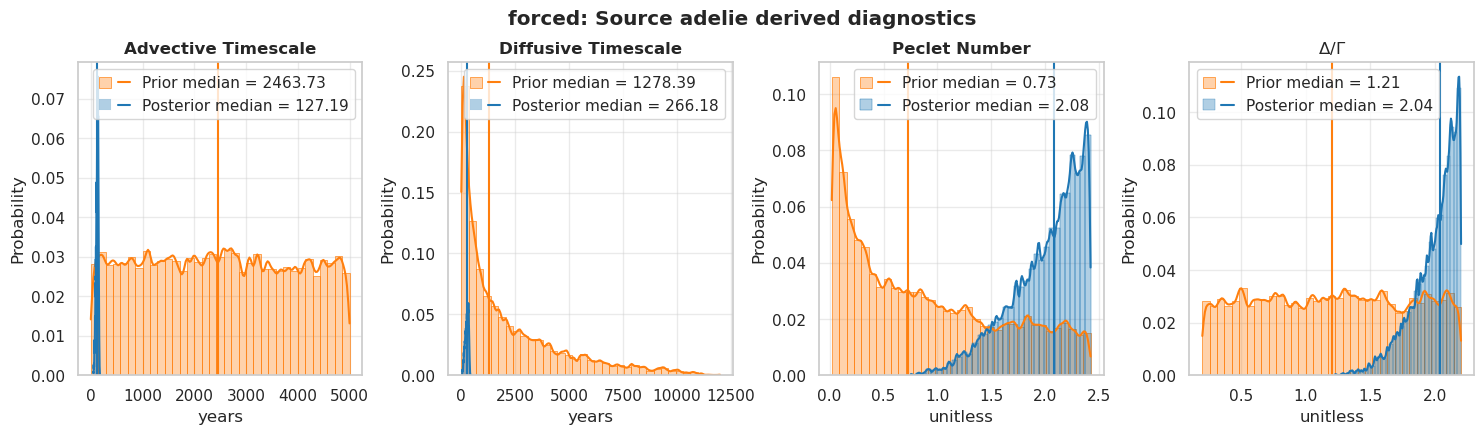

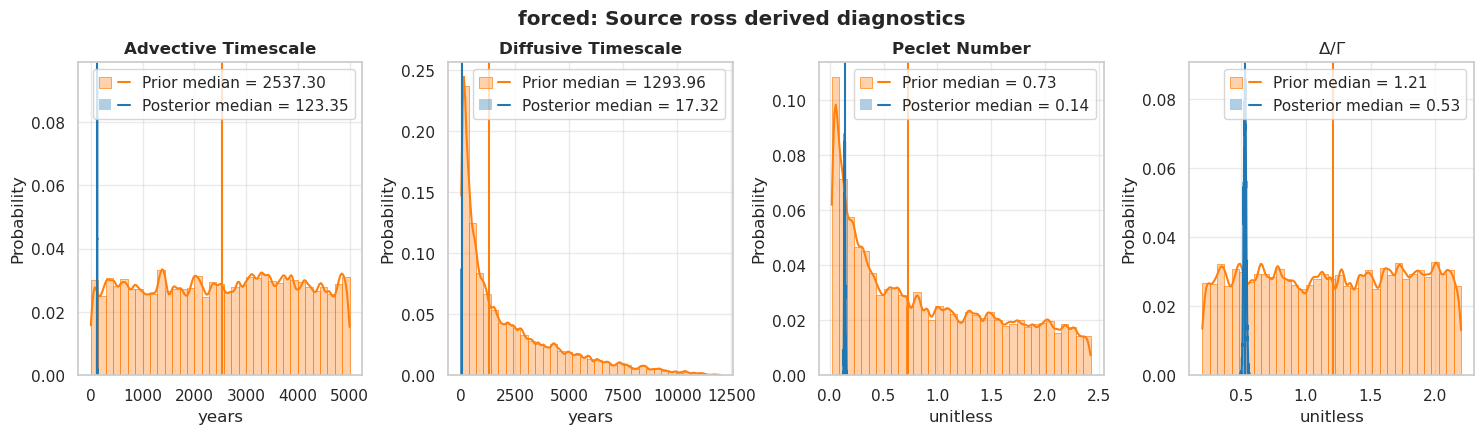

In [80]:
import importlib
import plot_ig_utils

plot_ig_utils = importlib.reload(plot_ig_utils)
plot_variable_marginals = plot_ig_utils.plot_variable_marginals

prior_color = 'tab:orange'
posterior_color = 'tab:blue'
truth_color = 'k'
kde_kws = {'cut': 0, 'clip': (0, np.inf), 'bw_adjust': 0.2}
hist_kws = dict(bins=35, stat='probability', alpha=0.35, kde=True, kde_kws=kde_kws)
diagnostic_names = ['advective_timescale', 'diffusive_timescale', 'peclet_number', 'delta_gamma_ratio']
target_diagnostics = ['Advective Timescale', 'Diffusive Timescale', 'Peclet Number', r'$\Delta / \Gamma$']

for expt in ds_b.expt.values:
    print(expt)
    for source in ds_b.source.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            diagnostic_names,
            target_diagnostics,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years', 'unitless', 'unitless'], strict=True):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Source {source} derived diagnostics', fontweight='bold', y=1.03)
        

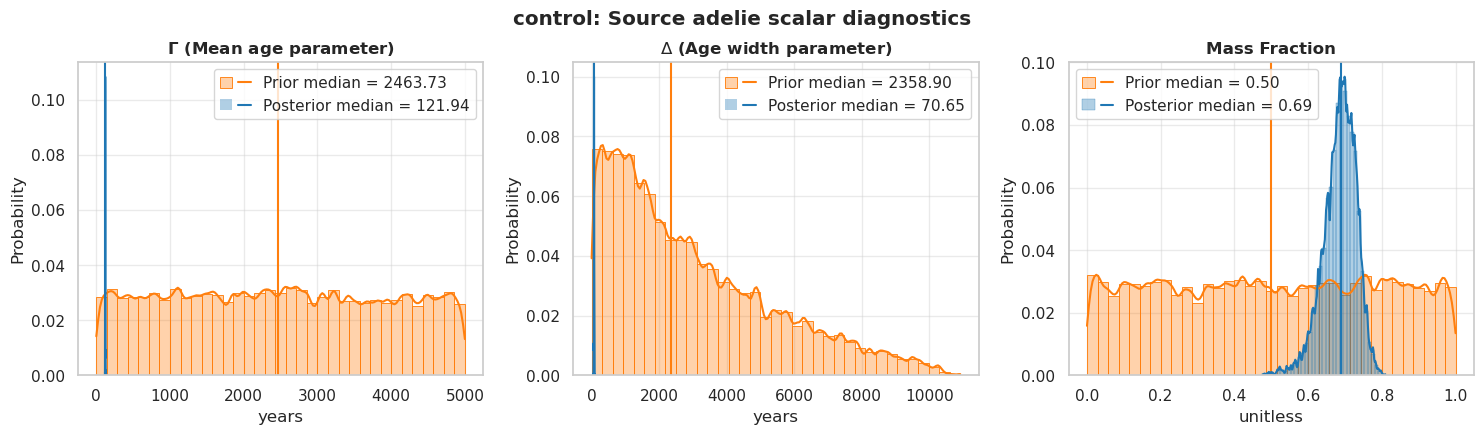

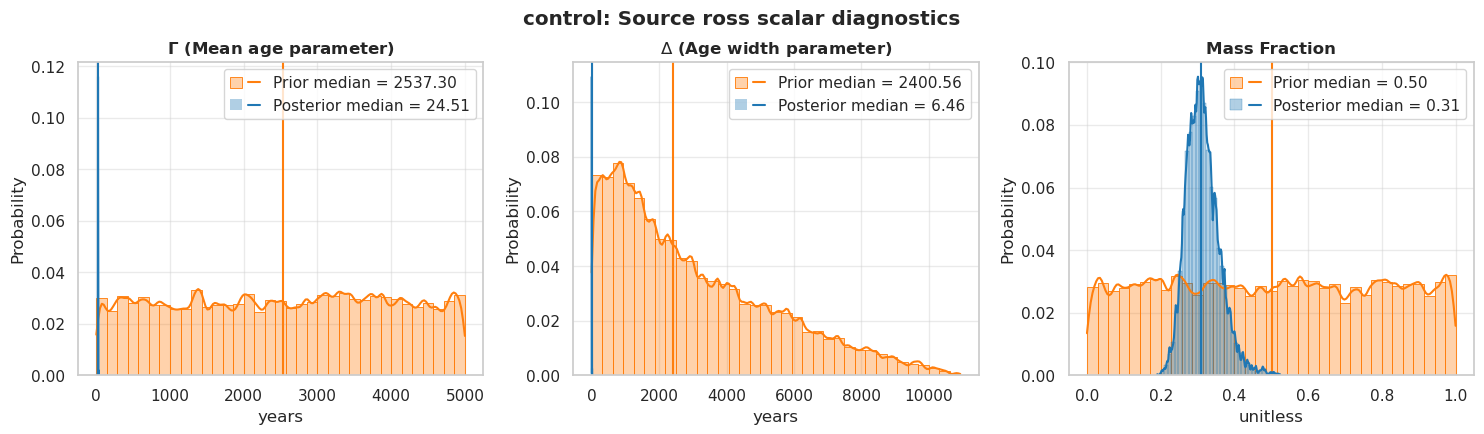

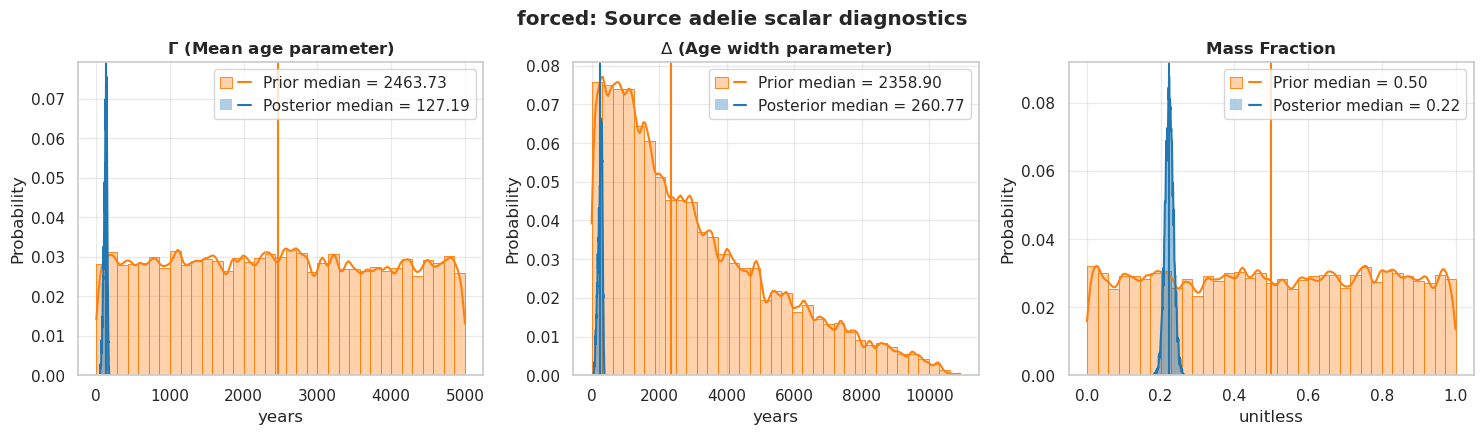

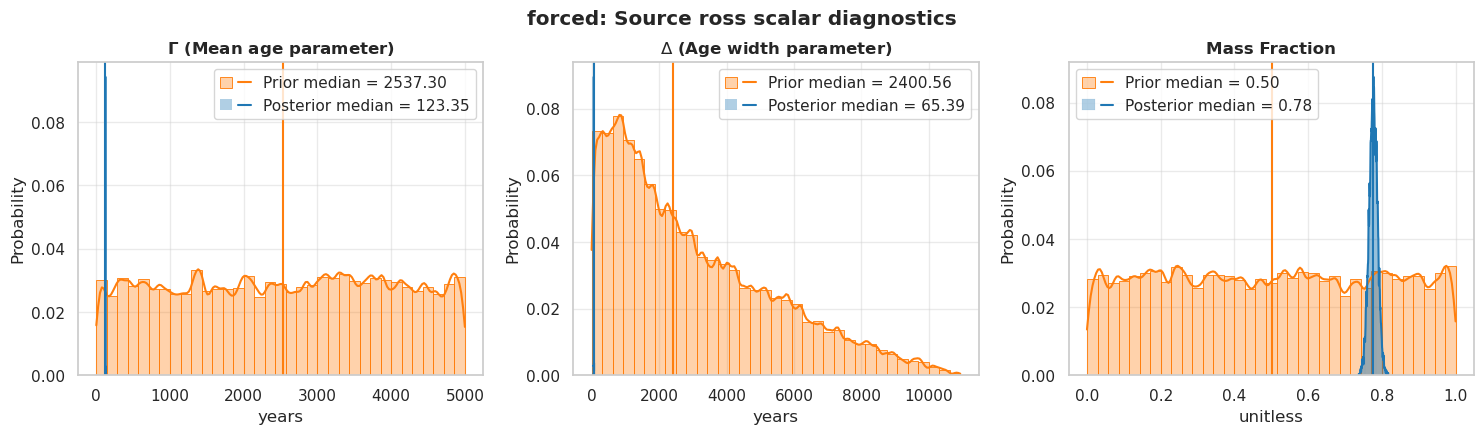

In [81]:
parameter_names = ['gamma', 'delta', 'mass_fraction']
target_parameters = [
    r'$\mathbf{\Gamma}$ (Mean age parameter)',
    r'$\Delta$ (Age width parameter)',
    'Mass Fraction',
]

for expt in ds_b.expt.values:
    for source in ds_b.source.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            parameter_names,
            target_parameters,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years', 'unitless', 'years'], strict=False):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Source {source} scalar diagnostics', fontweight='bold', y=1.03)

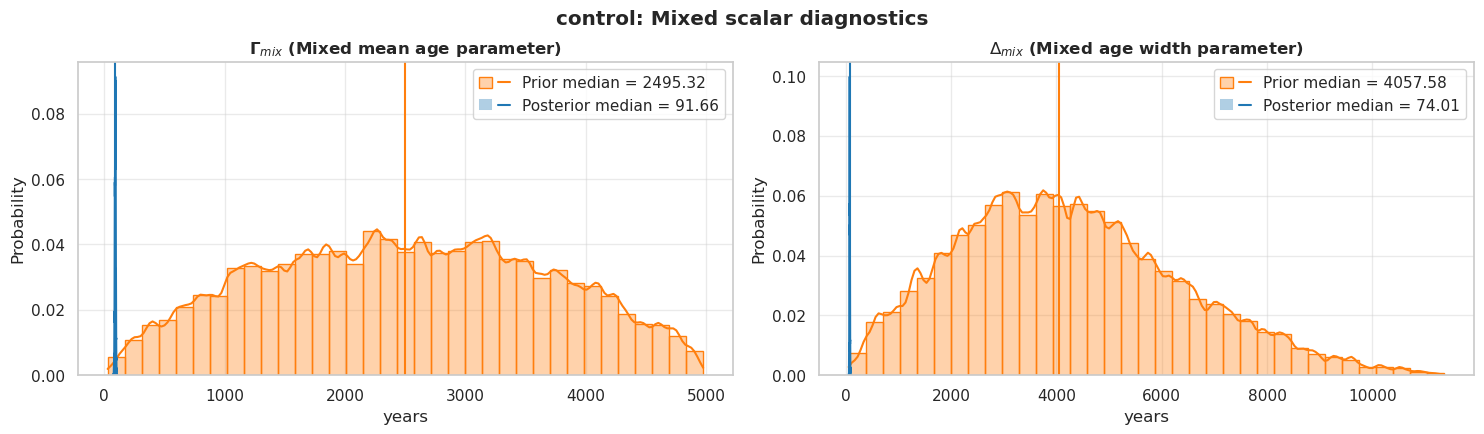

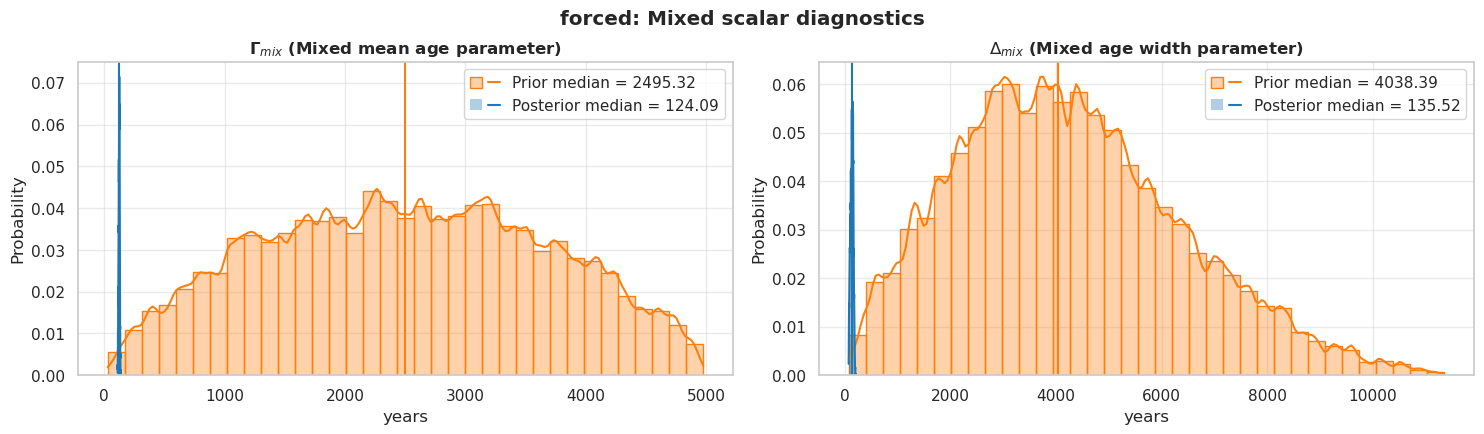

In [82]:
parameter_names = ['gamma_mix', 'delta_mix']
target_parameters = [
    r'$\mathbf{\Gamma}_{mix}$ (Mixed mean age parameter)',
    r'$\Delta_{mix}$ (Mixed age width parameter)'
]

for expt in ds_b.expt.values:
        fig, axes = plot_variable_marginals(
            prior.sel(expt = expt),
            posterior.sel(expt = expt),
            parameter_names,
            target_parameters,
            source=source,
            prior_color=prior_color,
            posterior_color=posterior_color,
            hist_kws=hist_kws,
        )
        for ax, units in zip(axes.ravel(), ['years', 'years',], strict=False):
            ax.set_xlabel(units)
        fig.suptitle(f'{expt}: Mixed scalar diagnostics', fontweight='bold', y=1.03)

In [83]:
# for expt in ds_b.expt.values:
#     plot_mixed_gamma_delta_joint(
#         posterior.sel(expt = expt),
#         source_label=str(source),
#         posterior_color=posterior_color,
#     )

In [84]:
prior_da = bayes_integrator.predict_sources(
    gamma=prior['gamma'], delta=prior['delta'], mass_fraction=prior['mass_fraction'],
    obs_times=ds_i['time'], boundary_time=ds_b['time'], boundary=ds_b['boundary'],
)
posterior_da = bayes_integrator.predict_sources(
    gamma=posterior['gamma'], delta=posterior['delta'], mass_fraction=posterior['mass_fraction'],
    obs_times=ds_i['time'], boundary_time=ds_b['time'], boundary=ds_b['boundary'],
)


In [88]:
 ds_i['interior'].sel(expt = expt)

<xarray.DataArray 'interior' (tracer: 3, time: 151)> Size: 2kB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 5.01086951e-27, 2.12026700e-30, 3.28617744e-18,
        1.33553813e-15, 8.81022414e-13, 1.12061601e-11, 7.60300434e-11,
        1.82253190e-09, 1.18333077e-08, 5.87224278e-08, 2.02933251e-07,
        4.30557662e-07, 9.60573971e-07, 1.57567752e-06, 2.60466277e-06,
        6.65876541e-06, 1.21645498e-05, 2.60963989e-05, 4.15538634e-05,
        7.44507051e-05, 9.34078344e-05, 1.38933246e-04, 1.66633356e-04,
        2.46582669e-04, 3.13148310e-04, 5.20613161e-04, 6.71991205e-04,
        1.07583811e-03, 1.73792173e-03, 2.14553089e-03, 2.78250454e-03,
        3.33601283e-03, 3.93438851e-03, 4.48628049e-03, 4.81205666e-03,
        5.80396783e-03, 6.70088315e-03, 7.84132537e-03, 1.04668131e-02,
        1.38080427e-02, 1.24402791e-02, 1.56774335e-02, 1.91787891e-02,
        2.32889354e-02, 2.62204334e-02, 2.72865146e-02, 3.21945660e-02,
        4.23275605e-02, 4.48397212e-02, 4.81990390e-02, 5.64017482e-02,
        6.28782883e-02, 6.64934292e-02, 6.93443269e-02, 8.69461298e-02,
        1.08563162e-01, 1.15882196e-01, 1.07019834e-01, 1.23932004e-01,
        1.44825459e-01, 1.48975000e-01, 1.79599434e-01, 1.87503621e-01,
        2.03174442e-01, 2.11411402e-01, 2.39371359e-01, 2.39382058e-01,
        2.70737082e-01, 2.58899719e-01, 2.33946383e-01, 2.55734891e-01,
        2.49287665e-01, 2.86165714e-01, 3.29855651e-01, 3.32469046e-01,
...
        3.66087258e-02, 3.56069691e-02, 3.26458104e-02, 3.73018570e-02,
        3.70944329e-02, 4.58036624e-02, 5.56551367e-02, 5.93627878e-02,
        5.67509644e-02, 5.68678305e-02, 6.80374131e-02, 6.88945726e-02,
        8.07547271e-02, 8.26232508e-02, 1.02857411e-01, 9.37821493e-02,
        9.70899463e-02, 9.96281430e-02, 9.97714847e-02, 1.20607413e-01,
        1.28477037e-01, 1.21560954e-01, 1.18292868e-01, 1.39441848e-01,
        1.47807732e-01, 1.40871659e-01, 1.47833258e-01, 1.46883637e-01,
        1.56192303e-01, 1.62202924e-01, 1.64982200e-01, 1.73563138e-01,
        1.99263111e-01, 2.20781907e-01, 2.11977586e-01, 2.15520561e-01,
        2.24221751e-01, 2.55026311e-01, 2.45444223e-01, 2.52336234e-01,
        2.98676193e-01, 2.89367080e-01, 3.27680916e-01, 3.27117324e-01,
        3.25303406e-01, 3.48044783e-01, 3.51457775e-01, 3.88157398e-01,
        4.03401583e-01, 3.92769188e-01, 4.07356292e-01, 4.08934504e-01,
        4.11927909e-01, 4.30096179e-01, 4.86318648e-01, 4.71236229e-01,
        4.98143762e-01, 4.85037148e-01, 4.82212901e-01, 5.14124155e-01,
        5.28476655e-01, 5.54370522e-01, 5.89202106e-01, 5.24788558e-01,
        5.86761892e-01, 6.08260989e-01, 6.30239129e-01, 6.10667765e-01,
        6.62498951e-01, 6.58429027e-01, 7.18097448e-01, 6.50398314e-01,
        7.17075109e-01, 7.44173467e-01, 7.45258510e-01, 7.79069424e-01,
        8.13708603e-01, 7.88718224e-01, 7.48763740e-01]], dtype=float32)
Coordinates:
  * tracer   (tracer) object 24B 'cfc11' 'cfc12' 'sf6'
  * time     (time) int64 1kB 1940 1941 1942 1943 1944 ... 2087 2088 2089 2090
    expt     <U7 28B 'control'
    lat      float64 8B -50.0
    lon      float64 8B 120.0
    z_l      float64 8B 6.5e+03
Attributes:
    regrid_method:  bilinear

In [90]:
for expt in ds_b.expt.values:
    posterior_mse = mse_score(posterior_da.sel(expt = expt), ds_i['interior'].sel(expt = expt),  ds_i['sigma_obs'].sel(expt = expt))
    print(
        f'{expt}: posterior predictive MSE = '
        f"{float(posterior_mse['mse'].quantile(0.5)):.4g} "
        f"[{float(posterior_mse['mse'].quantile(0.025)):.4g}, {float(posterior_mse['mse'].quantile(0.975)):.4g}]"
    )
    print(
        f'{expt}: posterior predictive RMSE = '
        f"{float(posterior_mse['rmse'].quantile(0.5)):.4g} "
        f"[{float(posterior_mse['rmse'].quantile(0.025)):.4g}, {float(posterior_mse['rmse'].quantile(0.975)):.4g}]"
    )

control: posterior predictive MSE = 1.268 [1.26, 1.287]
control: posterior predictive RMSE = 1.126 [1.122, 1.134]
forced: posterior predictive MSE = 7.366 [7.358, 7.384]
forced: posterior predictive RMSE = 2.714 [2.713, 2.717]


In [91]:
tau_plot = xr.DataArray(np.geomspace(0.1, 20000.0, 300), dims='tau', name='tau', attrs={'units': 'years'})
prior_components = xr_pdf(InverseGaussian, gamma=prior['gamma'], delta=prior['delta'])(tau_plot)
posterior_components = xr_pdf(InverseGaussian, gamma=posterior['gamma'], delta=posterior['delta'])(tau_plot)
prior_age_samples = (prior['mass_fraction'] * prior_components).sum('source')
posterior_age_samples = (posterior['mass_fraction'] * posterior_components).sum('source')

/tmp/ipykernel_94522/3627654571.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


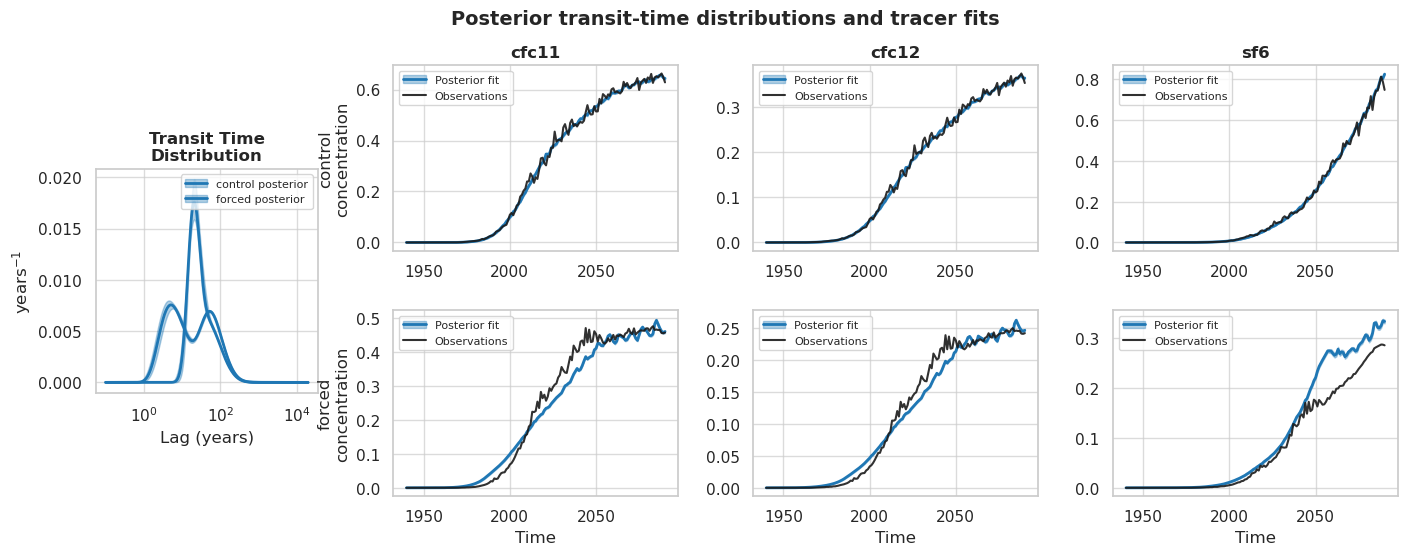

In [92]:
import matplotlib.pyplot as plt

expts, tracers = list(ds_b.expt.values), list(ds_i.tracer.values)
nrows, ncols = len(expts), len(tracers) + 1

fig = plt.figure(figsize=(4.2 * ncols, 2.8 * nrows))
gs = fig.add_gridspec(
    nrows, ncols,
    width_ratios=[0.9] + [1.15] * len(tracers),
    hspace=0.32, wspace=0.28,
)

# Left column is split vertically; TTD occupies only the middle cell.
gs_ttd = gs[:, 0].subgridspec(
    3, 1,
    height_ratios=[0.35, 1.0, 0.35],
)

ax_ttd = fig.add_subplot(gs_ttd[1, 0])
ttd_legend = {}

for expt in expts:
    plot_distribution(
        ax_ttd, tau_plot, posterior_age_samples.sel(expt=expt),
        posterior_color, f"{expt} posterior", legend=ttd_legend,
    )

ax_ttd.set(
    xscale="log", title="Transit Time\nDistribution",
    xlabel="Lag (years)", ylabel="years$^{-1}$",
)
ax_ttd.title.set_fontweight("bold")
ax_ttd.grid(alpha=0.7)
ax_ttd.legend(ttd_legend.values(), ttd_legend.keys(), fontsize=8)

for row, expt in enumerate(expts):
    for col, tracer in enumerate(tracers):
        ax = fig.add_subplot(gs[row, col + 1])
        legend = {}

        plot_distribution(
            ax, ds_i.time, posterior_da.sel(tracer=tracer, expt=expt),
            posterior_color, "Posterior fit", legend=legend,
        )

        obs, = ax.plot(
            ds_i.time, ds_i.interior.sel(tracer=tracer, expt=expt),
            color=truth_color, alpha=0.9,
        )
        legend["Observations"] = obs

        if row == 0:
            ax.set_title(str(tracer), fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{expt}\n{ds_i.interior.attrs.get('units', 'concentration')}")
        if row == nrows - 1:
            ax.set_xlabel("Time")

        ax.grid(alpha=0.7)
        ax.legend(legend.values(), legend.keys(), fontsize=8)

fig.suptitle("Posterior transit-time distributions and tracer fits", fontweight="bold", fontsize=14)
fig.tight_layout()